In [238]:
import torch
import equiv_dens.utils.base as utils
import equiv_dens.utils.orbitals as orbitals
from equiv_dens.utils.spherical_harmonics import spherical_harmonics
import equiv_dens.utils.spherical_harmonics_deriv as sph_deriv
import numpy as np
from torchviz import make_dot
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [430]:
coords = torch.randn(1, 3, 3)
coords.requires_grad = True
print('coords', coords)
max_L = 5
d, u = utils.calculate_distances_and_directions(coords, center=torch.zeros(1, 1, 3))
s = spherical_harmonics(max_L, u)
print('s requires grad', [ss.requires_grad for ss in s])
for L in range(len(s)):
    zeros = torch.zeros_like(s[L])
    s[L] = torch.where(torch.isnan(s[L]), zeros, s[L])  # making sure there are no nans to avoid NaNs
print('dist', d)
print('unit', u)
scales = [torch.randn(1, 1, 1, 1) for L in range(max_L + 1)]
widths = [torch.randn(1, 1, 1, 1)**2 for L in range(max_L + 1)]
coeffs = [torch.randn(1, 1, 2 * L + 1, 1) for L in range(max_L + 1)]
print([ss.shape for ss in s])
print('scales', scales)
print('widths', widths)
print('coeffs', coeffs)

coords tensor([[[-1.6021,  0.0449,  2.1932],
         [-0.3110,  0.0950, -0.3214],
         [-0.9302,  0.3541, -0.4158]]], requires_grad=True)
s requires grad [False, True, True, True, True]
dist tensor([[[2.7164],
         [0.4572],
         [1.0787]]], grad_fn=<LinalgVectorNormBackward0>)
unit tensor([[[ 0.5898, -0.0165, -0.8074],
         [ 0.6803, -0.2077,  0.7029],
         [ 0.8624, -0.3283,  0.3854]]], grad_fn=<DivBackward0>)
[torch.Size([1, 3, 1]), torch.Size([1, 3, 3]), torch.Size([1, 3, 5]), torch.Size([1, 3, 7]), torch.Size([1, 3, 9])]
scales [tensor([[[[0.3904]]]]), tensor([[[[0.7435]]]]), tensor([[[[0.6550]]]]), tensor([[[[-0.7723]]]]), tensor([[[[-0.1188]]]])]
widths [tensor([[[[2.5388]]]]), tensor([[[[0.0167]]]]), tensor([[[[0.8343]]]]), tensor([[[[0.0279]]]]), tensor([[[[0.0541]]]])]
coeffs [tensor([[[[-1.6183]]]]), tensor([[[[ 0.8508],
          [-1.3654],
          [-0.6322]]]]), tensor([[[[ 0.3195],
          [ 1.1390],
          [-1.1979],
          [-0.0763],
     

In [36]:
gto = 0

for L in range(max_L + 1):
    scale = scales[L]
    width = widths[L]
    coeff = coeffs[L]
    sph = s[L].unsqueeze(-1) * coeff
    print('sph shape', sph.shape)
    # if L == 1:
        # print('sL shape', s[L].shape)
        # print('sph grad', torch.autograd.grad(sph[0, 0, 0, 0], coords))
    rbf = orbitals.gaussian_rbf(d.unsqueeze(-1), width, scale, L)
    gto += torch.sum(rbf * sph, dim=(-2, -1))
print(gto)

sph shape torch.Size([1, 3, 1, 1])
scale shape torch.Size([1, 1, 1, 1])
width torch.Size([1, 1, 1, 1])
r shape torch.Size([1, 3, 1, 1])
L 0
sph shape torch.Size([1, 3, 3, 1])
scale shape torch.Size([1, 1, 1, 1])
width torch.Size([1, 1, 1, 1])
r shape torch.Size([1, 3, 1, 1])
L 1
sph shape torch.Size([1, 3, 5, 1])
scale shape torch.Size([1, 1, 1, 1])
width torch.Size([1, 1, 1, 1])
r shape torch.Size([1, 3, 1, 1])
L 2
tensor([[ 1.0691,  0.1063, -3.4645]], grad_fn=<AddBackward0>)


In [9]:
grad = torch.autograd.grad(gto[0,1], coords, retain_graph=True)
print(grad)

(tensor([[[-0.0000, -0.0000, -0.0000],
         [-0.4897, -0.3220, -0.5255],
         [-0.0000, -0.0000, -0.0000]]]),)


In [455]:
print('coords requires grad', coords.requires_grad)
print('u requires grad', u.requires_grad)
print('s requres grad', s[0].requires_grad)
print('coords', coords)
print('u', u)
gto = 0
gto_grad = 0
s_deriv = sph_deriv.spherical_harmonics_deriv(max_L, u)
dcoords = torch.eye(3).unsqueeze(0).unsqueeze(0)
print(dcoords.shape)
for L in range(max_L + 1):
    scale = scales[L]
    width = widths[L]
    coeff = coeffs[L]
    sph = s[L].unsqueeze(-1) * coeff
    print('L', L)
    print('coeff shape', coeff.shape)
    print('s[L] shape', s[L].shape)
    print('s[l] deriv shape', s_deriv[L].shape)
    print('sph', sph)
    sph_autograd = 0
    du = 0
    if L != 0:
        for i in range(sph.squeeze().shape[0]):
            for j in range(sph.squeeze().shape[1]):
                sph_autograd += torch.autograd.grad(sph.squeeze()[i, j], coords, retain_graph=True)[0]
                du += torch.autograd.grad(sph.squeeze()[i, j], u, retain_graph=True)[0]
                # print(sph_autograd)
    # print('sph du autograd', du)
    if L != 1:
        sph_grad = (s_deriv[L].unsqueeze(-1) * coeff.unsqueeze(0)).sum((-1, -2))
    else:
        sph_grad = (s_deriv[L].unsqueeze(-1) * coeff[..., [2, 0, 1], :]).sum(-1)
    # print('sph du deriv', sph_grad)
    # print('sph autograd', sph_autograd)
    sph_grad_c = sph_grad.unsqueeze(-2) * -(dcoords/d.unsqueeze(-1) -
                 (coords.unsqueeze(-2) * coords.unsqueeze(-1)/d.unsqueeze(-1)**3))
    sph_grad_c = sph_grad_c.sum(-1)
    # print('sph u and c ratio', sph_autograd / sph_grad)
    rbf = orbitals.gaussian_rbf(d.unsqueeze(-1), width, scale, L)
    rbf_autograd = 0
    for i in range(3):
        rbf_autograd += torch.autograd.grad(rbf.squeeze()[i], coords, retain_graph=True)[0]
    # print('rbf autograd', rbf_autograd)
    rbf_grad = orbitals.gaussian_rbf_deriv(d.unsqueeze(-1), width, scale, L).squeeze(-1) * coords / d
    # print('rbf_deriv', rbf_grad)
    print('coords.shape', coords.shape)
    gto_l = torch.sum(rbf * sph, dim=(-2, -1)) 
    gto_autograd = 0
    for i in range(3):
        gto_autograd += torch.autograd.grad(gto_l.squeeze()[i], coords, retain_graph=True)[0]
    print('rbf shape', rbf.shape)
    print('rbf grad shape', rbf_grad.shape)
    print('rbf grad unsqueeze shape', rbf_grad.unsqueeze(-2).shape)
    print('sph shape', sph.shape)
    print('sph deriv unsqueeze coords', sph_grad_c.unsqueeze(-1).shape) 
    print('rbf_grad unsqueeze * sph', (rbf_grad.unsqueeze(-2) * sph).shape)
    print('rbf* sph_grad unsqueeze ', (rbf * sph_grad_c.unsqueeze(-1)).shape)
    gto_deriv = torch.sum(rbf_grad.unsqueeze(-2) * sph, -2) + rbf.squeeze(-1) * sph_grad_c
    print('gto autograd', gto_autograd)
    print('gto deriv', gto_deriv)
    gto += gto_l 

# gto_autodiff = 0

coords requires grad True
u requires grad True
s requres grad False
coords tensor([[[-1.6021,  0.0449,  2.1932],
         [-0.3110,  0.0950, -0.3214],
         [-0.9302,  0.3541, -0.4158]]], requires_grad=True)
u tensor([[[ 0.5898, -0.0165, -0.8074],
         [ 0.6803, -0.2077,  0.7029],
         [ 0.8624, -0.3283,  0.3854]]], grad_fn=<DivBackward0>)
torch.Size([1, 1, 3, 3])
L 0
coeff shape torch.Size([1, 1, 1, 1])
s[L] shape torch.Size([1, 3, 1])
s[l] deriv shape torch.Size([1, 3, 1])
sph tensor([[[[-1.6183]],

         [[-1.6183]],

         [[-1.6183]]]])
coords.shape torch.Size([1, 3, 3])
rbf shape torch.Size([1, 3, 1, 1])
rbf grad shape torch.Size([1, 3, 3])
rbf grad unsqueeze shape torch.Size([1, 3, 1, 3])
sph shape torch.Size([1, 3, 1, 1])
sph deriv unsqueeze coords torch.Size([1, 3, 3, 1])
rbf_grad unsqueeze * sph torch.Size([1, 3, 1, 3])
rbf* sph_grad unsqueeze  torch.Size([1, 3, 3, 1])
gto autograd tensor([[[-4.5798e-29,  1.2845e-30,  6.2696e-29],
         [-1.5108e-01,  4.61

In [189]:
du = 0.0
for i in range(u.squeeze().shape[0]):
    for j in range(u.squeeze().shape[1]):
        du += torch.autograd.grad(u.squeeze()[i, j], coords, retain_graph=True)[0]

dcoords = torch.eye(3).unsqueeze(0).unsqueeze(-1)
dcoords = dcoords.expand((-1 ,-1 ,-1, 3))

u_deriv = -(1 / d - (coords * torch.sum(coords, dim=(-1), keepdim=True) / d**3))
print('du', du)
print('u_deriv', u_deriv)

du tensor([[[-0.3618, -1.3607,  0.3097],
         [-0.6257, -0.6337, -0.5279],
         [-0.2880, -0.4415, -0.6645]]])
u_deriv tensor([[[-0.3618, -1.3607,  0.3097],
         [-0.6257, -0.6337, -0.5279],
         [-0.2880, -0.4415, -0.6645]]], grad_fn=<NegBackward0>)


In [428]:
sph_grad = (s_deriv[1].unsqueeze(-1) * coeffs[1][..., [2, 0, 1], :]).sum(-1)
# sph_grad = (s_deriv[2].unsqueeze(-1) * coeffs[2]).sum((-1, -2))
print('sph grad shape', sph_grad.shape)
dcoords = torch.eye(3).unsqueeze(0).unsqueeze(0)
# dcoords = dcoords.expand((-1 , 3 ,-1, -1))
u_deriv = -(dcoords/d.unsqueeze(-1) - (coords.unsqueeze(-2) * coords.unsqueeze(-1)/d.unsqueeze(-1)**3))
print('u_deriv shape', u_deriv.shape)
print('u_deriv', (sph_grad.unsqueeze(-2) * u_deriv).sum(-1))

sph grad shape torch.Size([1, 3, 3])
u_deriv shape torch.Size([1, 3, 3, 3])
u_deriv tensor([[[ 0.0211, -0.5303, -0.3940],
         [ 0.0576, -0.5527, -0.4876],
         [ 0.6144, -0.2688,  0.0991]]], grad_fn=<SumBackward1>)


In [245]:
coords2 = torch.tensor(coords)
coords2.requires_grad = True
coeffs1 = torch.tensor(coeffs[1])
class Direction(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.dummy = torch.nn.Parameter(torch.ones((1, 3, 3)))

    def forward(self, Ri):
        Ri = Ri * self.dummy
        Rj = torch.zeros_like(Ri)
        rij = Rj - Ri  # displacement vectors
        dij = torch.norm(rij, dim=-1, keepdim=True)  # distances
        uij = rij / dij  # unit displacement vectors
        return uij

class L1(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.dummy = torch.nn.Parameter(torch.ones((1, 3, 3)))

    def forward(self, u):
        u = u * self.dummy
        print('u', u)
        return np.sqrt(3) * u[..., [1, 2, 0]] 

class SphCoeffs(torch.nn.Module):
    def __init__(self, coeffs):
        super().__init__()
        self.coeffs = torch.nn.Parameter(coeffs)

    def forward(self, s):
        return s.unsqueeze(-1) * self.coeffs

l1 = L1()
dir = Direction()
sphcoeffs = SphCoeffs(coeffs1)
model = torch.nn.Sequential(dir, l1, sphcoeffs)

print('coords', coords2)

sph_l1 = model(coords2)
# make_dot(sph_l1.mean(), params=dict(model.named_parameters()))
print("l1", sph_l1)
l = sph_l1.sum()
l.backward()
print('coords_grad', coords2.grad)
print('l1 dummy', l1.dummy.grad)
print('dir dummy', dir.dummy.grad)

coords tensor([[[-1.8399, -0.1225, -0.0045],
         [ 0.7088,  1.4892, -0.2280],
         [ 1.8345,  1.1303, -0.4510]]], requires_grad=True)
u tensor([[[ 0.9978,  0.0664,  0.0024],
         [-0.4257, -0.8944,  0.1369],
         [-0.8333, -0.5134,  0.2049]]], grad_fn=<MulBackward0>)
l1 tensor([[[[-0.0394],
          [-0.0007],
          [ 0.2080]],

         [[ 0.5310],
          [-0.0376],
          [-0.0887]],

         [[ 0.3048],
          [-0.0562],
          [-0.1737]]]], grad_fn=<MulBackward0>)
coords_grad tensor([[[-0.0222,  0.3280,  0.1490],
         [-0.2287,  0.1392,  0.1981],
         [-0.1230,  0.2522,  0.1316]]])
l1 dummy tensor([[[ 0.2080, -0.0394, -0.0007],
         [-0.0887,  0.5310, -0.0376],
         [-0.1737,  0.3048, -0.0562]]])
dir dummy tensor([[[ 0.0408, -0.0402, -0.0007],
         [-0.1621,  0.2072, -0.0452],
         [-0.2257,  0.2851, -0.0594]]])


/tmp/ipykernel_615990/1445518262.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  coords2 = torch.tensor(coords)
/tmp/ipykernel_615990/1445518262.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  coeffs1 = torch.tensor(coeffs[1])


In [270]:
coords2 = torch.tensor(coords)
coords2.requires_grad = True
coeffs1 = torch.tensor(coeffs[1])
d = torch.norm(coords2, dim=-1, keepdim=True)  # distances
d.retain_grad()
u = coords2 / d  # unit displacement vectors
u.retain_grad()
s = np.sqrt(3) * u[..., [1, 2, 0]]
s.retain_grad()
sph = s.unsqueeze(-1) * coeffs1
sph.retain_grad()

l = sph.sum()
l.backward(retain_graph=True)
print('coords grad', coords2.grad)
print('sph grad', sph.grad)
print('u grad', u.grad)
print('d grad', d.grad)

coords grad tensor([[[ 0.0222, -0.3280, -0.1490],
         [ 0.2287, -0.1392, -0.1981],
         [ 0.1230, -0.2522, -0.1316]]])
sph grad tensor([[[[1.],
          [1.],
          [1.]],

         [[1.],
          [1.],
          [1.]],

         [[1.],
          [1.],
          [1.]]]])
u grad tensor([[[ 0.2085, -0.5937, -0.2744],
         [ 0.2085, -0.5937, -0.2744],
         [ 0.2085, -0.5937, -0.2744]]])
d grad tensor([[[0.0911],
         [0.2431],
         [0.0340]]])


/tmp/ipykernel_615990/4174735444.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  coords2 = torch.tensor(coords)
/tmp/ipykernel_615990/4174735444.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  coeffs1 = torch.tensor(coeffs[1])


u grad tensor([[[-5.1092, -4.1135, -3.8367],
         [ 5.6651,  3.9788,  3.7376],
         [ 4.2140, -2.7020, -2.1191]]])
d grad tensor([[[-2.6420],
         [-3.3536],
         [ 1.6183]]])
c_pow2_sum grad tensor([[[-0.7389],
         [-0.9780],
         [ 0.4549]]])
c_pow2 grad tensor([[[-0.7389, -0.7389, -0.7389],
         [-0.9780, -0.9780, -0.9780],
         [ 0.4549,  0.4549,  0.4549]]])
one side? tensor([[[ 2.4703,  0.6202, -0.7022],
         [-3.1933, -0.8446,  0.5798],
         [-0.1566,  0.2296,  1.5943]]], grad_fn=<MulBackward0>)
coords grad tensor([[[-0.3876, -1.6807, -2.8483],
         [ 0.1107,  1.4760,  2.7597],
         [ 2.2124, -1.2893,  0.4030]]])
coords tensor([[[-1.6716, -0.4197,  0.4751],
         [ 1.6326,  0.4318, -0.2964],
         [-0.1721,  0.2524,  1.7524]]], requires_grad=True)
final grad? tensor([[[-0.3876, -1.6807, -2.8483],
         [ 0.1107,  1.4760,  2.7597],
         [ 2.2124, -1.2893,  0.4030]]], grad_fn=<AddBackward0>)


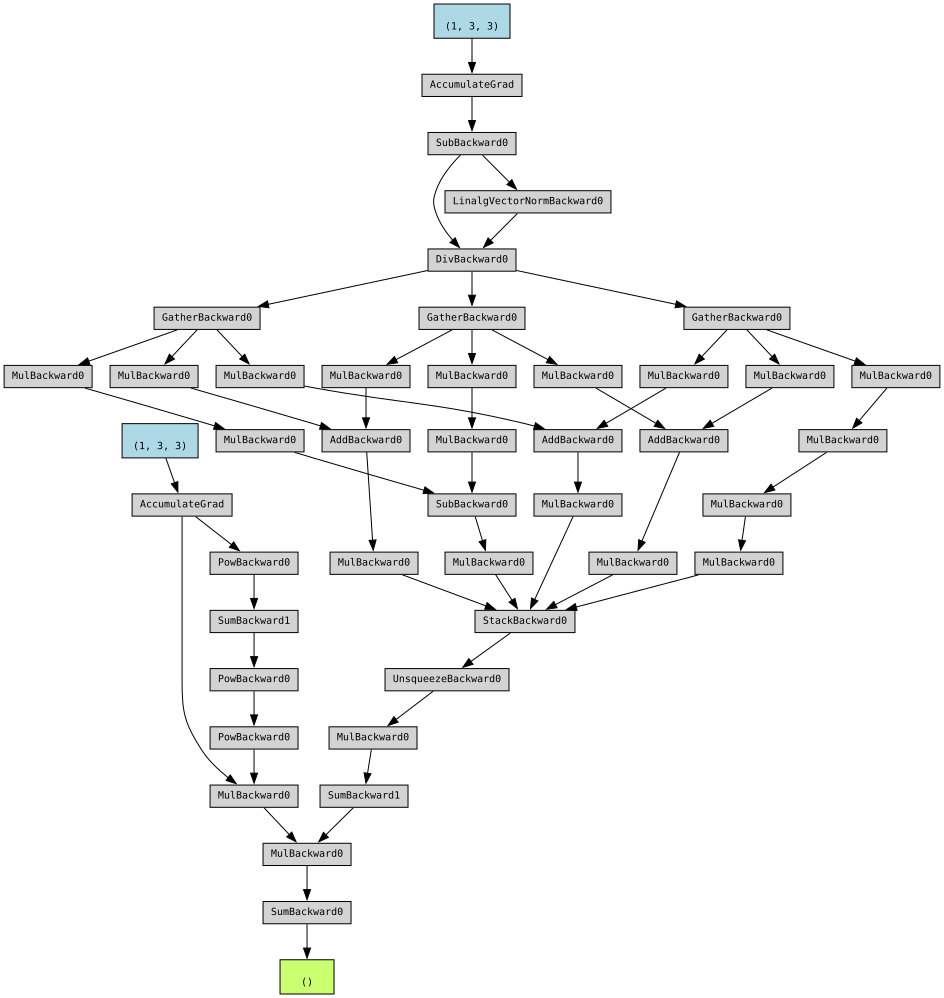

In [408]:
coords2 = coords.clone().detach()
coords2.requires_grad = True
coeffs1 = coeffs[2].clone().detach()
c_pow2 = coords2**2
c_pow2.retain_grad()
c_pow2_sum = c_pow2.sum(-1, keepdim=True)
c_pow2_sum.retain_grad()
d = c_pow2_sum**(0.5)
d.retain_grad()
u2 = coords2 * d**(-1)  # unit displacement vectors
u2.retain_grad()
l = (u2 * sph_grad).sum()
# l = u2.sum()
l.backward(retain_graph=True)
print('u grad', u2.grad)
print('d grad', d.grad)
print('c_pow2_sum grad', c_pow2_sum.grad)
print('c_pow2 grad', c_pow2.grad)
print('one side?', 2 * coords2 * c_pow2.grad)
print('coords grad', coords2.grad)
print('coords', coords)
print('final grad?', 2 * coords2 * c_pow2.grad + sph_grad/d)
make_dot(l)

In [409]:
s_deriv = sph_deriv.spherical_harmonics_deriv(2, u)

sph_grad = (s_deriv[2].unsqueeze(-1) * coeffs[2]).sum((-1,-2))
print('sph_grad.shape', sph_grad.shape)

dudr = -(1 / d - (coords * torch.sum(coords, dim=(-1), keepdim=True) / d**3)) 
dudd = (coords / -d**2)
dddp = 1/(2 *  torch.sqrt(torch.sum(coords**2, -1, keepdim=True)))
dpds = 2*coords
sph_grad_c = sph_grad * dudr
print('s grad', s_deriv[1])
print('sph_grad', sph_grad)
print('u grad r', dudr)
print('u grad d', (sph_grad*dudd).sum(-1, keepdim=True))
print('d grad sqrt', (sph_grad*dudd*dddp).sum(-1, keepdim=True))
print('sqrt grad sum', dpds*(sph_grad*dddp*dudd).sum(-1, keepdim=True))
print('sqrt grad sum', dpds*(sph_grad*dddp*dudd).sum(-1, keepdim=True))
print('sum up', sph_grad*1/d + dpds*(sph_grad*dddp*dudd).sum(-1, keepdim=True))
# print('second part', (coords * torch.sum(coords, dim=(-1), keepdim=True) / d**3))
# print('sph_grad_c', sph_grad_c)

sph_grad.shape torch.Size([1, 3, 3])
s grad tensor([[[1.7321, 1.7321, 1.7321],
         [1.7321, 1.7321, 1.7321],
         [1.7321, 1.7321, 1.7321]]])
sph_grad tensor([[[-5.1092, -4.1135, -3.8367],
         [ 5.6651,  3.9788,  3.7376],
         [ 4.2140, -2.7020, -2.1191]]], grad_fn=<SumBackward1>)
u grad r tensor([[[-0.0866, -0.4407, -0.6938],
         [-0.0106, -0.4318, -0.6872],
         [-0.6182, -0.4800,  0.0084]]], grad_fn=<NegBackward0>)
u grad d tensor([[[-2.6420],
         [-3.3536],
         [ 1.6183]]], grad_fn=<SumBackward1>)
d grad sqrt tensor([[[-0.7389],
         [-0.9780],
         [ 0.4549]]], grad_fn=<SumBackward1>)
sqrt grad sum tensor([[[ 2.4703,  0.6202, -0.7022],
         [-3.1933, -0.8446,  0.5798],
         [-0.1566,  0.2296,  1.5943]]], grad_fn=<MulBackward0>)
sqrt grad sum tensor([[[ 2.4703,  0.6202, -0.7022],
         [-3.1933, -0.8446,  0.5798],
         [-0.1566,  0.2296,  1.5943]]], grad_fn=<MulBackward0>)
sum up tensor([[[-0.3876, -1.6807, -2.8483],
     